In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Rutas
BASE_PATH = Path('/app/data/raw')
TRAIN_PATH = BASE_PATH / 'Training_Set/Training_Set'
VAL_PATH = BASE_PATH / 'Evaluation_Set/Evaluation_Set'
TEST_PATH = BASE_PATH / 'Test_Set/Test_Set'

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


In [2]:
# Rutas
BASE_PATH = Path('/app/data/raw')
TRAIN_PATH = BASE_PATH / 'Training_Set/Training_Set'
VAL_PATH = BASE_PATH / 'Evaluation_Set/Evaluation_Set'
TEST_PATH = BASE_PATH / 'Test_Set/Test_Set'

# Cargar labels
train_df = pd.read_csv(TRAIN_PATH / 'RFMiD_Training_Labels.csv')
val_df = pd.read_csv(VAL_PATH / 'RFMiD_Validation_Labels.csv')
test_df = pd.read_csv(TEST_PATH / 'RFMiD_Testing_Labels.csv')

print(f"Train: {len(train_df)} imágenes")
print(f"Val: {len(val_df)} imágenes")
print(f"Test: {len(test_df)} imágenes")
print(f"\nTotal: {len(train_df) + len(val_df) + len(test_df)} imágenes")


Train: 1920 imágenes
Val: 640 imágenes
Test: 640 imágenes

Total: 3200 imágenes


In [3]:
print("Columnas del dataset:")
print(train_df.columns.tolist())
print("\nPrimeras 5 filas:")
train_df.head()

Columnas del dataset:
['ID', 'Disease_Risk', 'DR', 'ARMD', 'MH', 'DN', 'MYA', 'BRVO', 'TSLN', 'ERM', 'LS', 'MS', 'CSR', 'ODC', 'CRVO', 'TV', 'AH', 'ODP', 'ODE', 'ST', 'AION', 'PT', 'RT', 'RS', 'CRS', 'EDN', 'RPEC', 'MHL', 'RP', 'CWS', 'CB', 'ODPM', 'PRH', 'MNF', 'HR', 'CRAO', 'TD', 'CME', 'PTCR', 'CF', 'VH', 'MCA', 'VS', 'BRAO', 'PLQ', 'HPED', 'CL']

Primeras 5 filas:


,ID,Disease_Risk,DR,ARMD,MH,DN,MYA,BRVO,TSLN,ERM,...,CME,PTCR,CF,VH,MCA,VS,BRAO,PLQ,HPED,CL
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# Ver todas las columnas de enfermedades
disease_cols = train_df.columns[2:].tolist()  # Excluir ID y Disease_Risk

print(f"Total de enfermedades: {len(disease_cols)}")
print("\nEnfermedades:")
for i, col in enumerate(disease_cols, 1):
    print(f"{i}. {col}")

Total de enfermedades: 45

Enfermedades:
1. DR
2. ARMD
3. MH
4. DN
5. MYA
6. BRVO
7. TSLN
8. ERM
9. LS
10. MS
11. CSR
12. ODC
13. CRVO
14. TV
15. AH
16. ODP
17. ODE
18. ST
19. AION
20. PT
21. RT
22. RS
23. CRS
24. EDN
25. RPEC
26. MHL
27. RP
28. CWS
29. CB
30. ODPM
31. PRH
32. MNF
33. HR
34. CRAO
35. TD
36. CME
37. PTCR
38. CF
39. VH
40. MCA
41. VS
42. BRAO
43. PLQ
44. HPED
45. CL


In [6]:
print("Distribución de Disease_Risk:")
print(train_df['Disease_Risk'].value_counts().sort_index())

print("\n" + "="*50)
print("Porcentajes:")
print(train_df['Disease_Risk'].value_counts(normalize=True).sort_index() * 100)

Distribución de Disease_Risk:
Disease_Risk
0     401
1    1519
Name: count, dtype: int64

Porcentajes:
Disease_Risk
0    20.885417
1    79.114583
Name: proportion, dtype: float64


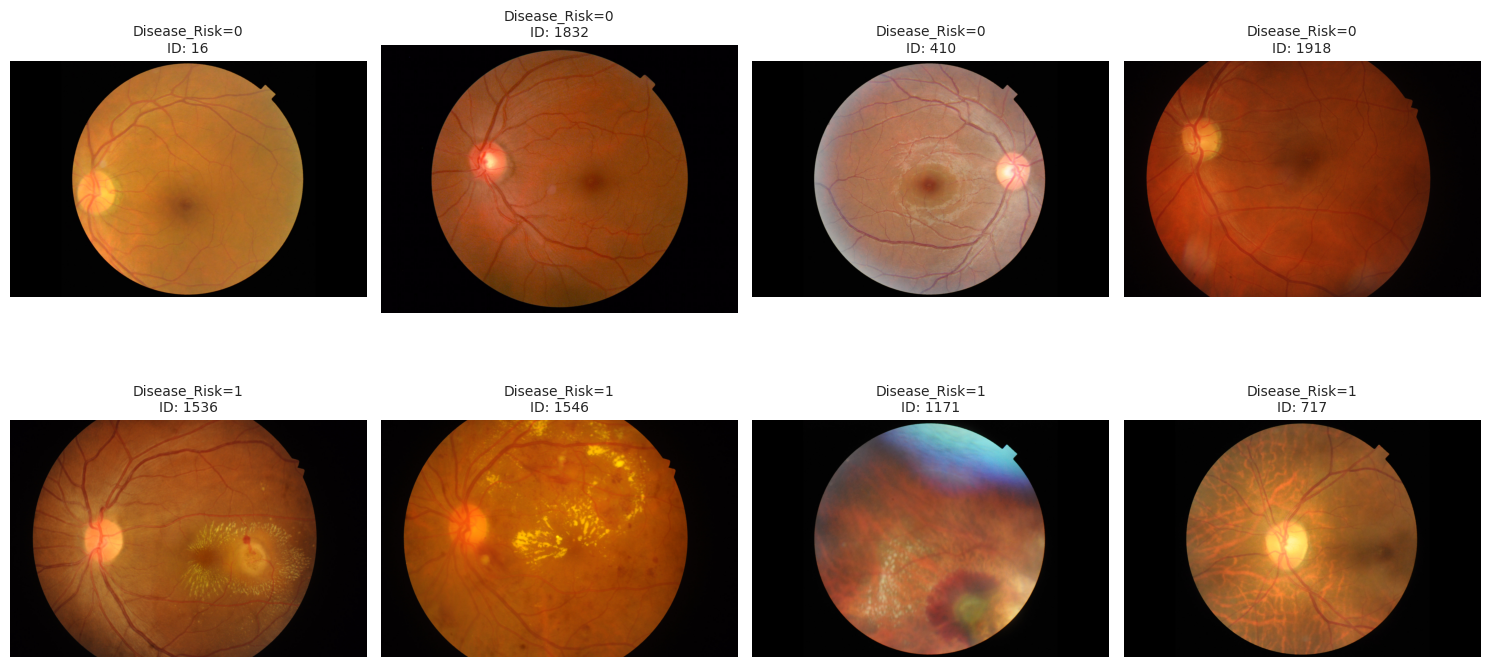

In [7]:
import random

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

# 4 imágenes de cada clase
for idx, disease_risk in enumerate([0, 1]):
    samples = train_df[train_df['Disease_Risk'] == disease_risk].sample(4)
    
    for i, (_, row) in enumerate(samples.iterrows()):
        img_id = row['ID']
        img_path = TRAIN_PATH / 'Training' / f"{img_id}.png"
        
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        ax = axes[idx * 4 + i]
        ax.imshow(img)
        ax.set_title(f"Disease_Risk={disease_risk}\nID: {img_id}", fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.show()

In [8]:
# Verificar tamaño de algunas imágenes
img_sizes = []

for i in range(10):  # Revisar 10 imágenes random
    img_id = train_df.sample(1)['ID'].values[0]
    img_path = TRAIN_PATH / 'Training' / f"{img_id}.png"
    img = cv2.imread(str(img_path))
    img_sizes.append(img.shape)

print("Tamaños de imágenes (height, width, channels):")
for size in set(img_sizes):
    count = img_sizes.count(size)
    print(f"{size}: {count} imágenes")

Tamaños de imágenes (height, width, channels):
(2848, 4288, 3): 2 imágenes
(1536, 2048, 3): 2 imágenes
(1424, 2144, 3): 6 imágenes


In [9]:
print("="*60)
print("RESUMEN DEL DATASET")
print("="*60)

print(f"\n📊 DATOS:")
print(f"  - Train: {len(train_df)} imágenes")
print(f"  - Val: {len(val_df)} imágenes")
print(f"  - Test: {len(test_df)} imágenes")

print(f"\n🎯 CLASES (Disease_Risk):")
print(f"  - Clase 0 (Sano): {(train_df['Disease_Risk']==0).sum()} ({(train_df['Disease_Risk']==0).mean()*100:.1f}%)")
print(f"  - Clase 1 (Enfermo): {(train_df['Disease_Risk']==1).sum()} ({(train_df['Disease_Risk']==1).mean()*100:.1f}%)")

print(f"\n📐 IMÁGENES:")
print(f"  - Tamaños variables (mayoría ~1424x2144)")
print(f"  - Formato: PNG, 3 canales (RGB)")

print(f"\n💡 PRÓXIMOS PASOS:")
print("  1. Preprocesamiento: Resize a 224x224")
print("  2. Data Augmentation para clase minoritaria")
print("  3. Class weights para desbalance")
print("  4. Transfer Learning con MobileNetV2")

RESUMEN DEL DATASET

📊 DATOS:
  - Train: 1920 imágenes
  - Val: 640 imágenes
  - Test: 640 imágenes

🎯 CLASES (Disease_Risk):
  - Clase 0 (Sano): 401 (20.9%)
  - Clase 1 (Enfermo): 1519 (79.1%)

📐 IMÁGENES:
  - Tamaños variables (mayoría ~1424x2144)
  - Formato: PNG, 3 canales (RGB)

💡 PRÓXIMOS PASOS:
  1. Preprocesamiento: Resize a 224x224
  2. Data Augmentation para clase minoritaria
  3. Class weights para desbalance
  4. Transfer Learning con MobileNetV2
